## Deep Learning

#### Chapter 18: Cats and Dogs Classification with CNN

A **Convolutional Neural Network (CNN)** is a class of deep learning models specifically designed to process grid-structured topology data, such as images. Unlike traditional fully connected networks that flatten images into 1D vectors (losing spatial relationship details), CNNs preserve spatial structure and local dependencies.

#### How CNNs Extract Features:
1. **Convolutional Layers (Convolutions):** These layers use small, learnable filters (or kernels) that slide across the input image. As the filter moves, it computes dot products to create a **Feature Map**. Early layers detect basic patterns like edges, lines, and textures, while deeper layers combine these patterns to identify complex shapes (like eyes, noses, ears, or tails).
2. **Activation Functions (ReLU):** Applied immediately after convolutions to introduce non-linearity, enabling the model to learn complex, non-linear relationships within the visual features.
3. **Pooling Layers (Max Pooling):** These layers downsample the feature maps to reduce spatial dimensions and computational complexity. They also provide **translational invariance**, allowing the network to recognize features even if they are slightly shifted in the frame.
4. **Dense (Fully Connected) Layers:** Once features are extracted, they are flattened and sent through standard dense layers to classify the image (e.g., determining whether the features belong to a "Cat" or a "Dog").

### From Images to Pixels: Constructing the Input

Before a computer can process an image of a cat or a dog, the visual representation must be translated into numerical data that a neural network can understand.

#### 1. Image Representation as Pixels
An image is essentially a grid of pixels. For a color image, each pixel is represented by three intensity values corresponding to the **Red, Green, and Blue (RGB)** color channels:
* **Width & Height:** The resolution of the image (for example, $200 \times 200$ pixels).
* **Channels:** 3 channels (RGB) for color images, or 1 channel for grayscale.
* **Pixel Values:** Each pixel value is an integer ranging from `0` (completely dark/black) to `255` (completely bright/white).

Therefore, a single color image of size $200 \times 200$ is represented as a 3D matrix (tensor) with dimensions of `(200, 200, 3)`, totaling $120,000$ individual numerical values.

#### 2. Input Pipeline and Preprocessing
To feed these images into our CNN effectively, we perform several preprocessing steps:
* **Resizing:** Images in the wild come in various sizes. We resize all input images to a uniform target size of `(200, 200)` to ensure consistency in our model's input layer.
* **Batching:** Instead of passing images one by one, we group them into "batches" (e.g., `batch_size=32`). This makes the training process more stable and computationally efficient. The input shape becomes `(32, 200, 200, 3)`.
* **Rescaling (Normalization):** Neural networks perform better with small input values. We rescale our pixel values from the range `[0, 255]` to `[0, 1]` by dividing every pixel by `255.0` (using the `layers.Rescaling(1./255)` layer).

In [11]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("aleemaparakatta/cats-and-dogs-mini-dataset")

print("Path to dataset files:", path)

100%|██████████| 21.9M/21.9M [00:00<00:00, 96.7MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/aleemaparakatta/cats-and-dogs-mini-dataset/versions/1


In [16]:
# Get the total images of cats and dogs in this dataset by pointing to the correct subdirectory
import os

# The cats_set and dogs_set directories are directly under the download path
pet_images_dir = path

total_cats = len([f for f in os.listdir(os.path.join(pet_images_dir, "cats_set")) if
                  f.lower().endswith(('.png', '.jpg', '.jpeg'))])
total_dogs = len([f for f in os.listdir(os.path.join(pet_images_dir, "dogs_set")) if
                  f.lower().endswith(('.png', '.jpg', '.jpeg'))])

print(f"Total cats: {total_cats}")
print(f"Total dogs: {total_dogs}")

Total cats: 500
Total dogs: 500


Dataset contents: ['cats_set', 'dogs_set']

--- First 20 Cat Pictures ---


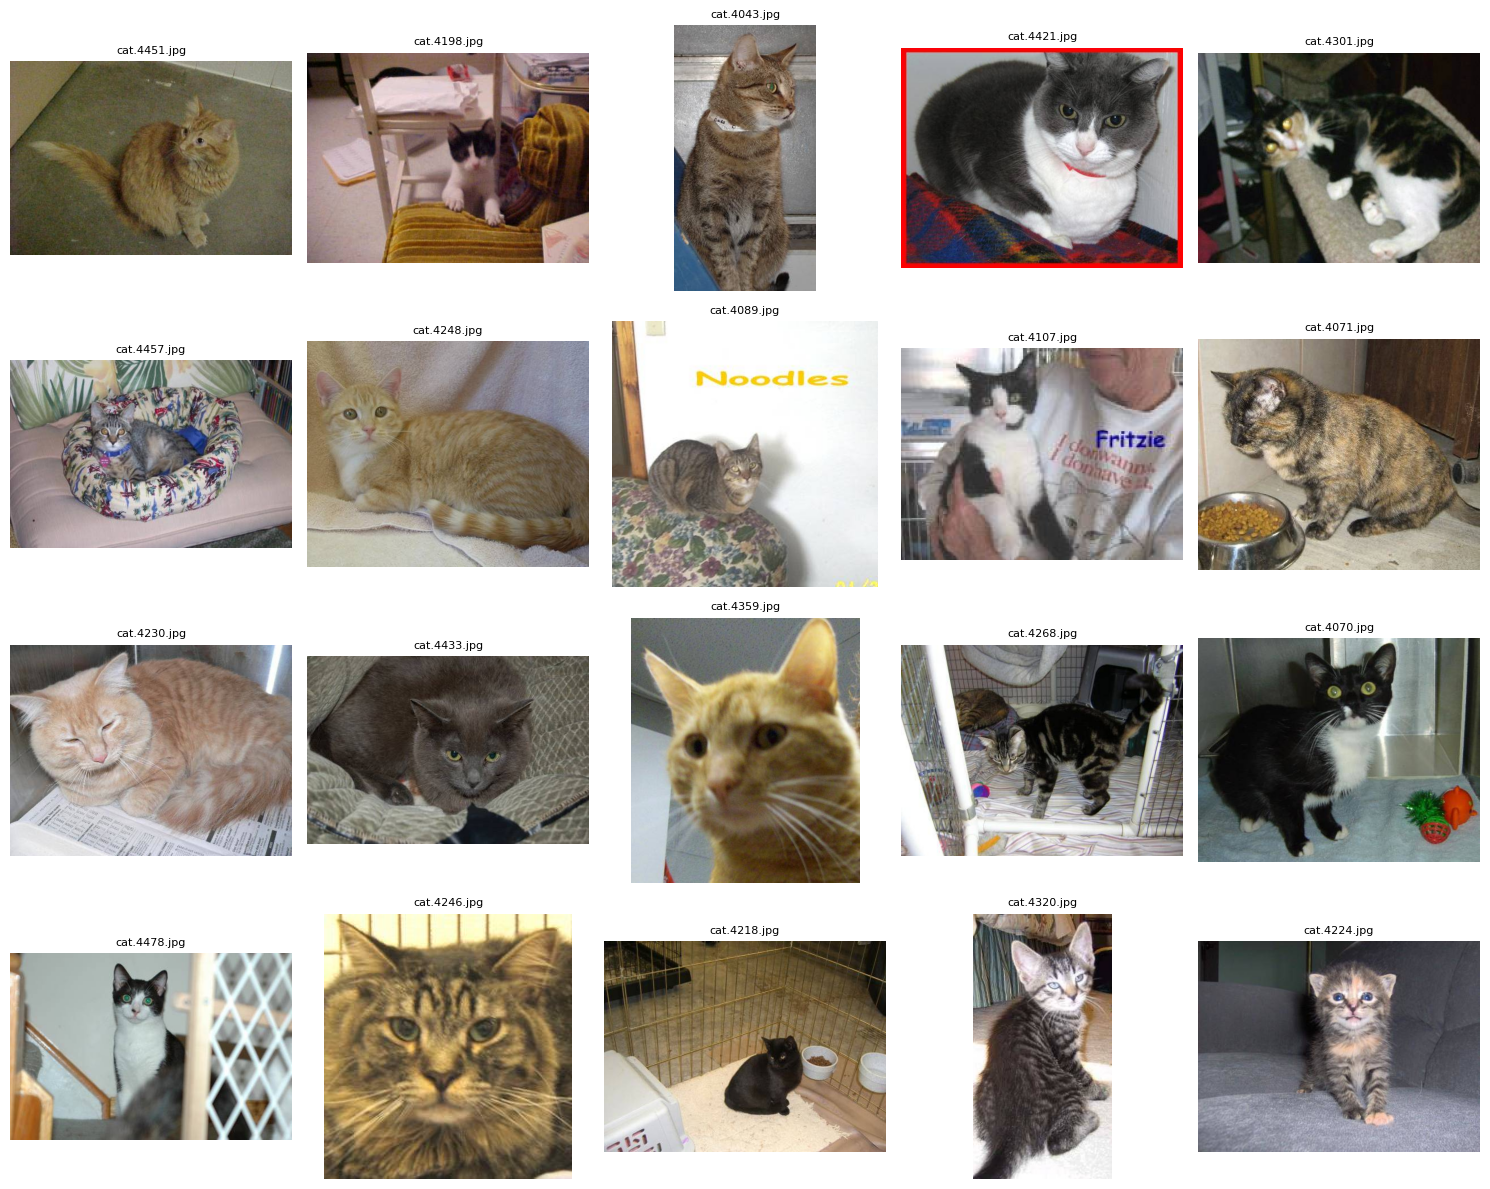


--- First 20 Dog Pictures ---


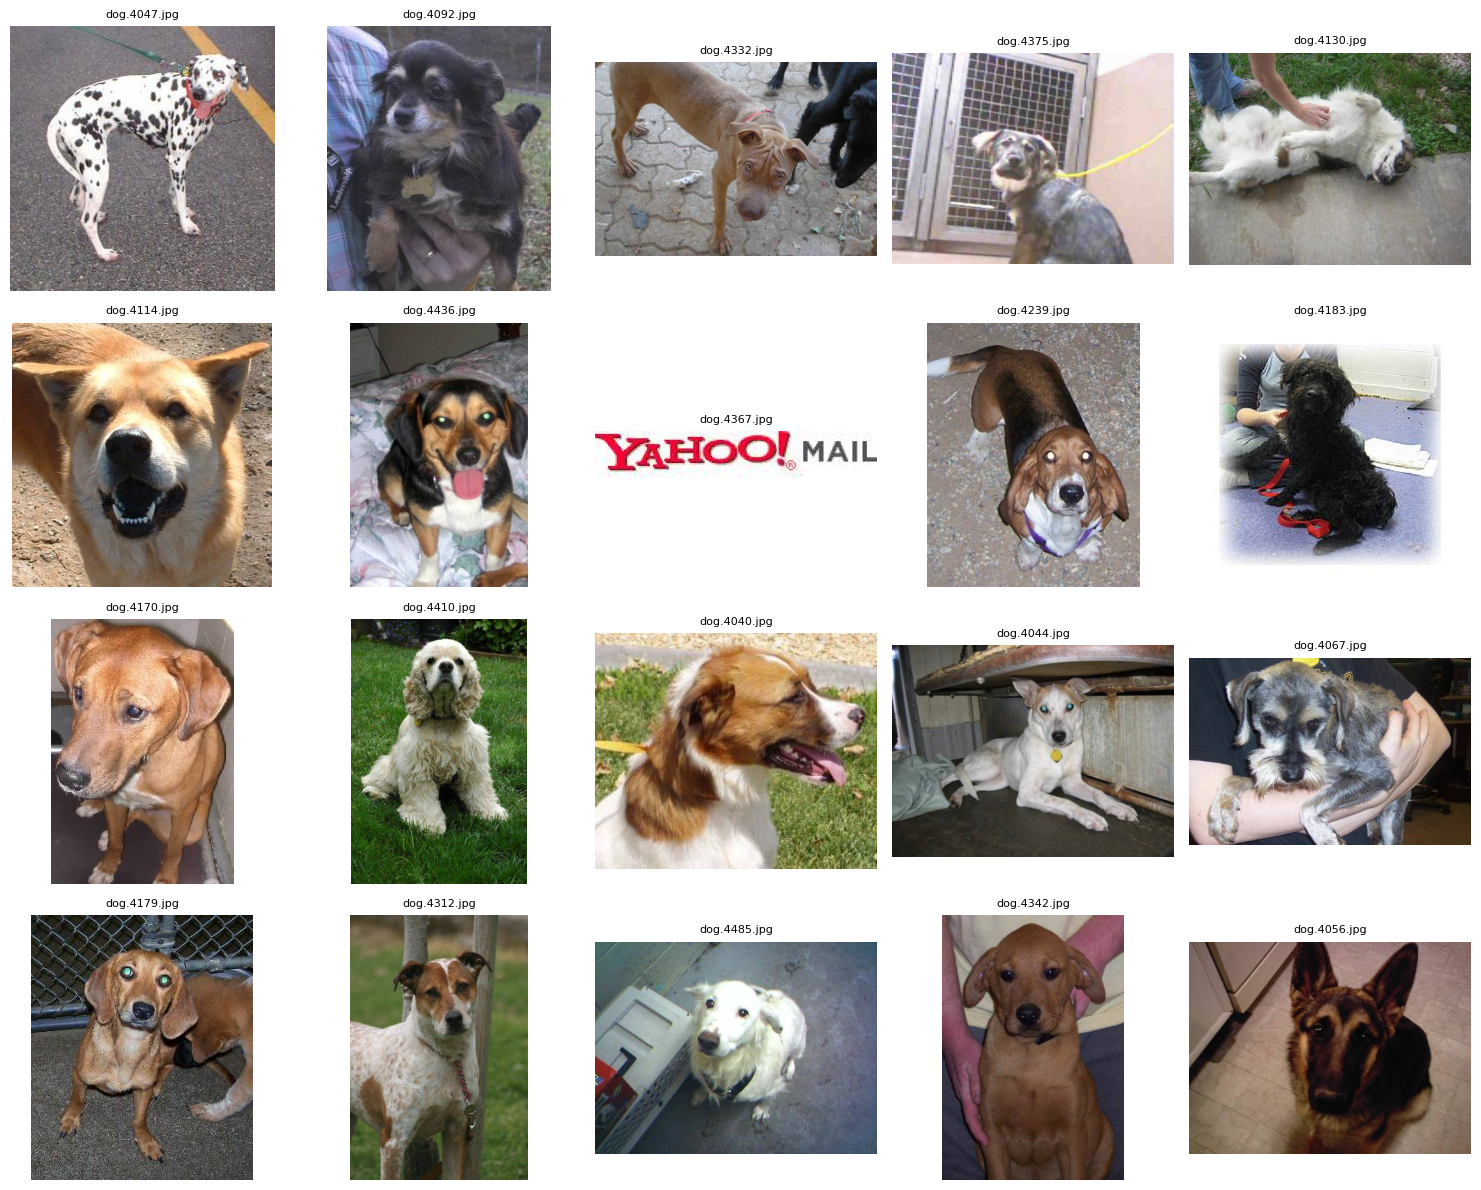

In [20]:
import os
import matplotlib.pyplot as plt
from PIL import Image

# Explore the dataset structure
dataset_path = path
print("Dataset contents:", os.listdir(dataset_path))

# We will recursively find image files for cats and dogs
all_files = []
for root, dirs, files in os.walk(dataset_path):
    for file in files:
        if file.lower().endswith(('.png', '.jpg', '.jpeg')):
            all_files.append(os.path.join(root, file))

# Filter and slice the first 10 cat and dog images
cat_images = [f for f in all_files if 'cats_set' in f][:20]
dog_images = [f for f in all_files if 'dogs_set' in f][:20]

def display_images(image_paths, title):
    print(f"\n--- {title} ---")
    if not image_paths:
        print("No images found.")
        return

    num_images = len(image_paths)
    cols = 5
    rows = (num_images + cols - 1) // cols

    fig, axes = plt.subplots(rows, cols, figsize=(15, 3 * rows))
    axes = axes.flatten() if num_images > 1 else [axes]

    for i in range(len(axes)):
        if i < num_images:
            img = Image.open(image_paths[i])
            axes[i].imshow(img)
            axes[i].axis('off')
            axes[i].set_title(os.path.basename(image_paths[i]), fontsize=8)
        else:
            axes[i].axis('off')

    plt.tight_layout()
    plt.show()

display_images(cat_images, "First 20 Cat Pictures")
display_images(dog_images, "First 20 Dog Pictures")

In [21]:
import tensorflow as tf
from tensorflow.keras.utils import image_dataset_from_directory
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Correcting path
base_dir = path

# Create train and test datasets
train_datagen = image_dataset_from_directory(base_dir,
                                             image_size=(200, 200),
                                             subset='training',
                                             seed=1,
                                             validation_split=0.1,
                                             batch_size=32)
test_datagen = image_dataset_from_directory(base_dir,
                                            image_size=(200, 200),
                                            subset='validation',
                                            seed=1,
                                            validation_split=0.1,
                                            batch_size=32)

Found 1000 files belonging to 2 classes.
Using 900 files for training.
Found 1000 files belonging to 2 classes.
Using 100 files for validation.


In [22]:
from tensorflow.keras import layers

model = tf.keras.models.Sequential([
    layers.Rescaling(1./255, input_shape=(200, 200, 3)),
    layers.Conv2D(32, (3, 3), activation='relu'),
    layers.MaxPooling2D(2, 2),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D(2, 2),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D(2, 2),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D(2, 2),

    layers.Flatten(),
    layers.Dense(512, activation='relu'),
    layers.BatchNormalization(),
    layers.Dense(512, activation='relu'),
    layers.Dropout(0.1),
    layers.BatchNormalization(),
    layers.Dense(512, activation='relu'),
    layers.Dropout(0.2),
    layers.BatchNormalization(),
    layers.Dense(1, activation='sigmoid')
])

model.summary()

/usr/local/lib/python3.13/dist-packages/keras/src/layers/preprocessing/data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling_1 (Rescaling)         │ (None, 200, 200, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 198, 198, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 99, 99, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 97, 97, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 48, 48, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 46, 46, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 23, 23, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 21, 21, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 10, 10, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 6400)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 512)            │     3,277,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 512)            │       262,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 512)            │       262,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │           513 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,902,529 (14.89 MB)

 Trainable params: 3,899,457 (14.88 MB)

 Non-trainable params: 3,072 (12.00 KB)

In [23]:
model.compile(
    loss='binary_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

# Train for 1 epoch to save time
history = model.fit(train_datagen,
                    epochs=10,
                    validation_data=test_datagen)

# Save the model
model.save('cats_and_dogs_model.keras')
print("Model saved successfully as 'cats_and_dogs_model.keras'")

Epoch 1/10
29/29 ━━━━━━━━━━━━━━━━━━━━ 74s 2s/step - accuracy: 0.5111 - loss: 0.9575 - val_accuracy: 0.6000 - val_loss: 0.6954
Epoch 2/10
29/29 ━━━━━━━━━━━━━━━━━━━━ 64s 2s/step - accuracy: 0.5644 - loss: 0.7629 - val_accuracy: 0.4900 - val_loss: 1.0072
Epoch 3/10
29/29 ━━━━━━━━━━━━━━━━━━━━ 80s 2s/step - accuracy: 0.6011 - loss: 0.7241 - val_accuracy: 0.4800 - val_loss: 1.4812
Epoch 4/10
29/29 ━━━━━━━━━━━━━━━━━━━━ 63s 2s/step - accuracy: 0.6378 - loss: 0.6665 - val_accuracy: 0.5200 - val_loss: 1.0540
Epoch 5/10
29/29 ━━━━━━━━━━━━━━━━━━━━ 81s 2s/step - accuracy: 0.6733 - loss: 0.6362 - val_accuracy: 0.4800 - val_loss: 0.9831
Epoch 6/10
29/29 ━━━━━━━━━━━━━━━━━━━━ 63s 2s/step - accuracy: 0.6967 - loss: 0.5806 - val_accuracy: 0.4900 - val_loss: 0.8103
Epoch 7/10
29/29 ━━━━━━━━━━━━━━━━━━━━ 83s 2s/step - accuracy: 0.7489 - loss: 0.5090 - val_accuracy: 0.5400 - val_loss: 0.8038
Epoch 8/10
29/29 ━━━━━━━━━━━━━━━━━━━━ 62s 2s/step - accuracy: 0.7200 - loss: 0.5793 - val_accuracy: 0.5200 - val_loss:

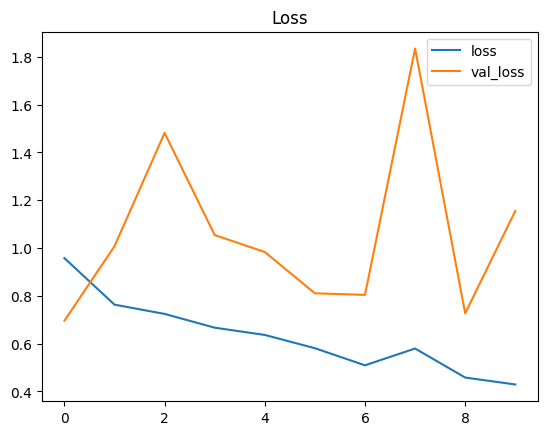

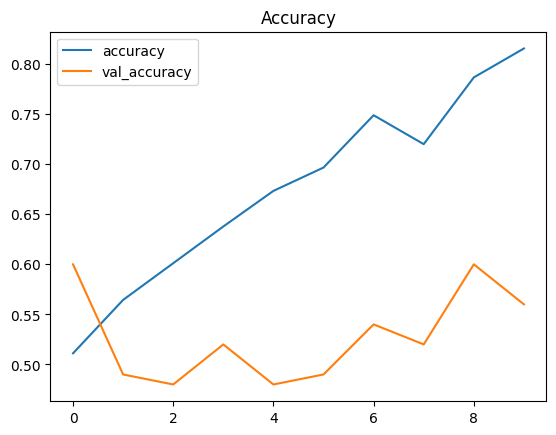

In [24]:
history_df = pd.DataFrame(history.history)
history_df.loc[:, ['loss', 'val_loss']].plot()
plt.title("Loss")
plt.show()

history_df.loc[:, ['accuracy', 'val_accuracy']].plot()
plt.title("Accuracy")
plt.show()

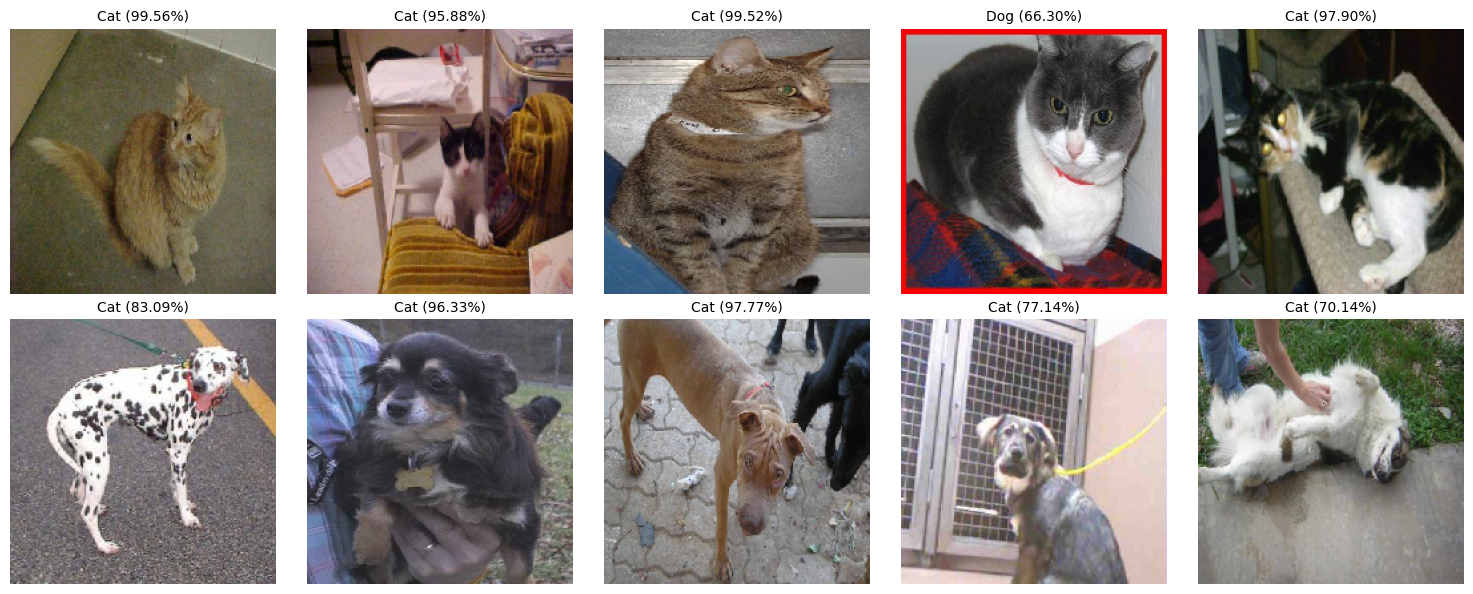

In [25]:
from tensorflow.keras.preprocessing import image

def predict_and_plot(cat_paths, dog_paths):
    fig, axes = plt.subplots(2, 5, figsize=(15, 6))

    # Row 0: Cats
    for i, img_path in enumerate(cat_paths[:5]):
        img = image.load_img(img_path, target_size=(200, 200))
        img_array = image.img_to_array(img)
        img_batch = np.expand_dims(img_array, axis=0)

        pred = model.predict(img_batch, verbose=0)[0][0]
        label = "Dog" if pred >= 0.5 else "Cat"
        confidence = pred if pred >= 0.5 else (1.0 - pred)

        axes[0, i].imshow(img)
        axes[0, i].set_title(f"{label} ({confidence:.2%})", fontsize=10)
        axes[0, i].axis('off')

    # Row 1: Dogs
    for i, img_path in enumerate(dog_paths[:5]):
        img = image.load_img(img_path, target_size=(200, 200))
        img_array = image.img_to_array(img)
        img_batch = np.expand_dims(img_array, axis=0)

        pred = model.predict(img_batch, verbose=0)[0][0]
        label = "Dog" if pred >= 0.5 else "Cat"
        confidence = pred if pred >= 0.5 else (1.0 - pred)

        axes[1, i].imshow(img)
        axes[1, i].set_title(f"{label} ({confidence:.2%})", fontsize=10)
        axes[1, i].axis('off')

    plt.tight_layout()
    plt.show()

predict_and_plot(cat_images, dog_images)

### Dropout Regularization & Model Serialization

Before resuming training, it is crucial to understand key techniques for refining neural networks and managing long-running experiments.

#### 1. What is Dropout?
**Dropout** is a powerful regularization technique used to prevent **overfitting** (where a model performs exceptionally well on training data but poorly on unseen test data).
* During each training step, Dropout randomly "drops out" (sets to zero) a fraction of neurons in a layer (e.g., $10\%$ or $20\%$ using `layers.Dropout(0.1)` or `0.2`).
* This forces the network to learn redundant representations and prevents neurons from co-adapting too closely to specific training samples.
* At test/prediction time, all neurons are active, but their outputs are scaled down proportionally.

#### 2. The Importance of Saving and Loading Models
Deep learning models can take hours, days, or even weeks to train fully. Saving a model's state (its architecture, weights, and optimizer configuration) to disk is essential because:
* **No Need to Retrain:** It allows you to pause training and resume exactly where you left off later without starting from scratch.
* **Portability:** You can train your model on high-performance hardware (like a GPU/TPU in Colab) and easily deploy it to a production server, mobile device, or edge computer for real-time predictions.
* **Version Control:** You can save checkpoints at different stages of training to roll back to previous iterations if the model begins to overfit or diverge.

In [26]:
import tensorflow as tf
import pandas as pd
import matplotlib.pyplot as plt

# Load the previously saved model
try:
    model = tf.keras.models.load_model('cats_and_dogs_model.keras')
    print("Successfully loaded previous model!")
except Exception as e:
    print(f"Could not load saved model. Error: {e}")

# Compile the loaded model
model.compile(
    loss='binary_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

# Train for 10 more epochs
history_additional = model.fit(train_datagen,
                              epochs=10,
                              validation_data=test_datagen)

# Save the model after additional training
model.save('cats_and_dogs_model.keras')
print("Model trained for an additional 10 epochs and saved successfully!")

Successfully loaded previous model!
Epoch 1/10
29/29 ━━━━━━━━━━━━━━━━━━━━ 69s 2s/step - accuracy: 0.8078 - loss: 0.4339 - val_accuracy: 0.5400 - val_loss: 1.0174
Epoch 2/10
29/29 ━━━━━━━━━━━━━━━━━━━━ 79s 2s/step - accuracy: 0.8433 - loss: 0.3520 - val_accuracy: 0.5900 - val_loss: 1.2698
Epoch 3/10
29/29 ━━━━━━━━━━━━━━━━━━━━ 62s 2s/step - accuracy: 0.8944 - loss: 0.2627 - val_accuracy: 0.6300 - val_loss: 0.8986
Epoch 4/10
29/29 ━━━━━━━━━━━━━━━━━━━━ 83s 2s/step - accuracy: 0.9333 - loss: 0.1622 - val_accuracy: 0.5800 - val_loss: 1.3480
Epoch 5/10
29/29 ━━━━━━━━━━━━━━━━━━━━ 62s 2s/step - accuracy: 0.9356 - loss: 0.1578 - val_accuracy: 0.5000 - val_loss: 3.1755
Epoch 6/10
29/29 ━━━━━━━━━━━━━━━━━━━━ 82s 2s/step - accuracy: 0.8756 - loss: 0.3046 - val_accuracy: 0.6600 - val_loss: 1.2374
Epoch 7/10
29/29 ━━━━━━━━━━━━━━━━━━━━ 82s 2s/step - accuracy: 0.9211 - loss: 0.1869 - val_accuracy: 0.5600 - val_loss: 1.0664
Epoch 8/10
29/29 ━━━━━━━━━━━━━━━━━━━━ 63s 2s/step - accuracy: 0.9567 - loss: 0.113

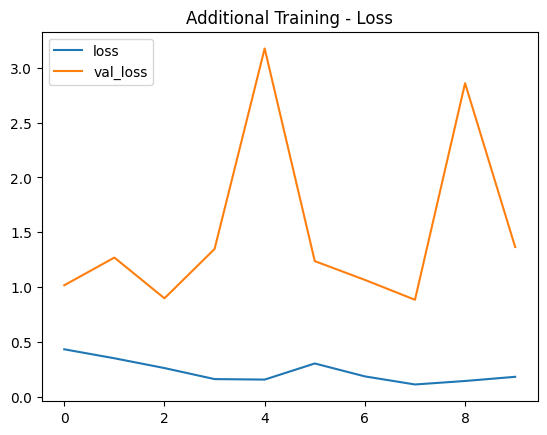

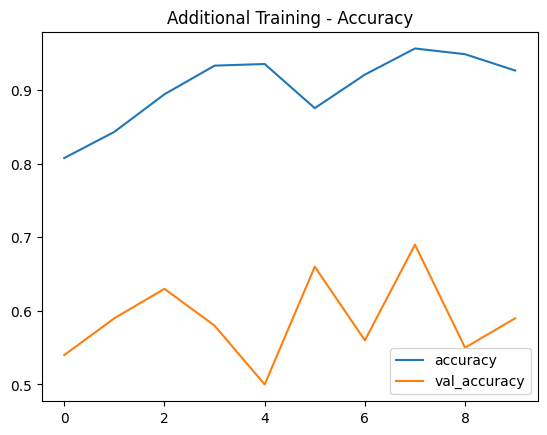

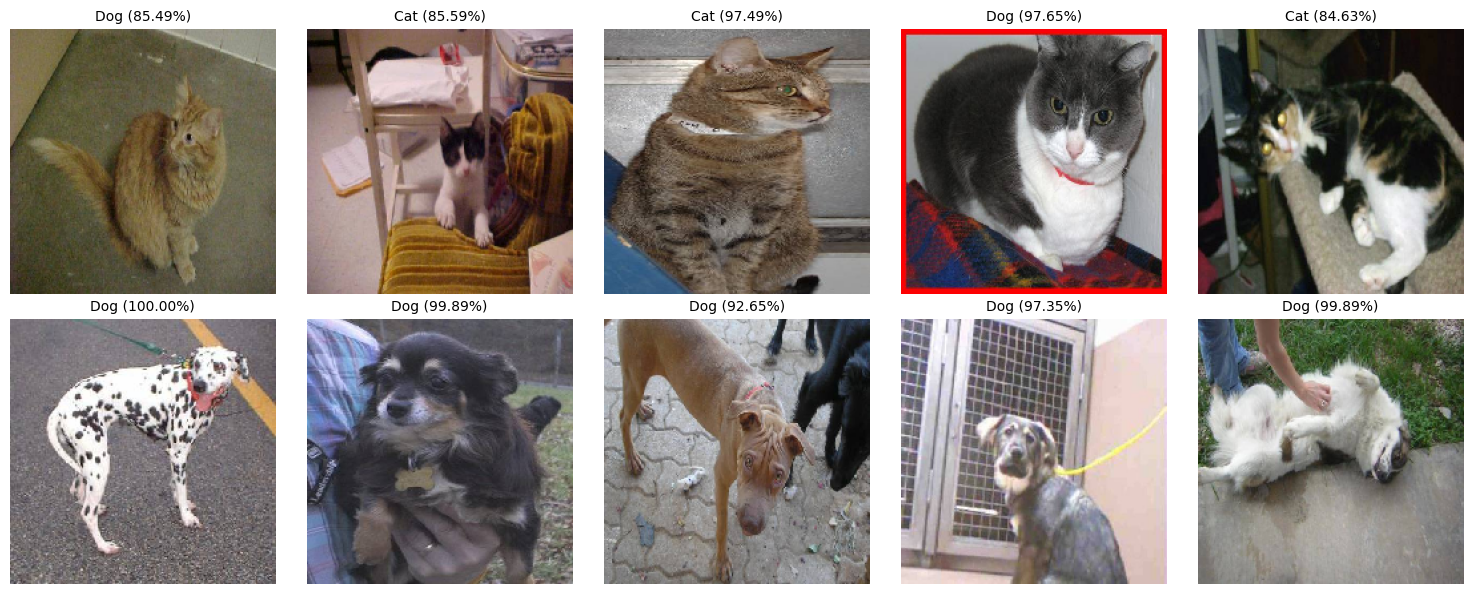

In [27]:
# Plot the additional training history
history_df_additional = pd.DataFrame(history_additional.history)
history_df_additional.loc[:, ['loss', 'val_loss']].plot()
plt.title("Additional Training - Loss")
plt.show()

history_df_additional.loc[:, ['accuracy', 'val_accuracy']].plot()
plt.title("Additional Training - Accuracy")
plt.show()

# Predict and plot the first 5 cats and dogs again
predict_and_plot(cat_images, dog_images)